## Analysis notebook of ovrlpy analysis for publication:

#### Comparison to a Baysor analysis of Xenium-derived mouse brain data.

In this notebook, we want to use ovrlpy to investigate the performance of baysor around detected regions of cell overlap and compare baysor's interpretation of overlapping signal to our tool's.

In [1]:
%matplotlib inline

In [2]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import ovrlpy
import pandas as pd
import seaborn as sns
from matplotlib_scalebar.scalebar import ScaleBar

/dh-projects/ag-ishaque/analysis/muellni/envs/ovrlpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import sys

import matplotlib

sys.path.append("../..")
from ovrlpy._plotting import _plot_signal_integrity

from utils import CM, FONT, read_mapmycells_zip, save_kwargs

matplotlib.rc("font", **FONT)

In [4]:
from pathlib import Path

data_folder = Path(
    "/dh-projects/ag-ishaque/raw_data/tiesmeys-ovrlpy/Xenium-brain-2024/replicate1"
)

#### Package import, parameters:

In [5]:
coordinate_df_3d = pd.read_csv(
    "segmentation.csv",
    usecols=["cell", "gene", "x", "y", "z"],
    dtype={"cell": "category"},
)

In [6]:
cells = pd.read_csv("segmentation_cell_stats.csv", index_col=0).rename(
    columns={"x": "centroid_x", "y": "centroid_y"}
)

In [7]:
adata = ad.io.read_loom("segmentation_counts.loom", var_names="Name", obs_names="Name")

# remove unnecessary information for upload to MapMyCells
adata.obs = adata.obs[[]]
adata.obs.index.name = "cell"

adata.write_h5ad("baysor.h5ad", compression="gzip")

del adata

#### Create a count matrix to re-celltype with mapmycells:

In [8]:
mapmycells_df = read_mapmycells_zip(
    "baysor_10xWholeMouseBrain(CCN20230722)_CorrelationMapping_UTC_1750759273608.zip"
)

In [9]:
coordinate_df_3d = coordinate_df_3d.merge(
    (
        mapmycells_df[["class_name", "cluster_name"]]
        .rename(columns={"class_name": "celltype", "cluster_name": "cluster"})
        .astype("category")
    ),
    how="left",
    left_on="cell",
    right_on="cell_id",
)

In [10]:
xlim = (2800, 4800)
ylim = (550, 1400)

In [11]:
area_of_interest = cells["centroid_x"].between(*xlim) & cells["centroid_y"].between(
    *ylim
)

area_vlmc = area_of_interest & (cells["centroid_y"] < 1220)

vlmc = mapmycells_df["subclass_name"].str.contains("VLMC")

plain_vlmc_mask = area_vlmc & vlmc & cells["centroid_x"].between(3200, 3850)

overlap_vlmc_mask = area_vlmc & vlmc & ~plain_vlmc_mask
overlap_vlmc_mask &= ~((cells["centroid_x"] > 4250) & (cells["centroid_y"] > 900))

In [12]:
clean_vlmcs = cells[plain_vlmc_mask]
fold_vlmcs = cells[overlap_vlmc_mask]
total_vlmcs = cells[plain_vlmc_mask | overlap_vlmc_mask]

In [13]:
coordinate_df_3d_clean_vlmcs = coordinate_df_3d[
    coordinate_df_3d["cell"].isin(clean_vlmcs.index)
]
coordinate_df_3d_fold_vlmcs = coordinate_df_3d[
    coordinate_df_3d["cell"].isin(fold_vlmcs.index)
]
coordinate_df_3d_vlmcs = coordinate_df_3d[
    coordinate_df_3d["cell"].isin(total_vlmcs.index)
]

In [14]:
ax_kwargs = dict(
    facecolor="k", aspect="equal", xlabel=None, ylabel=None, xticks=[], yticks=[]
)
ax_lims = dict(xlim=xlim, ylim=ylim)

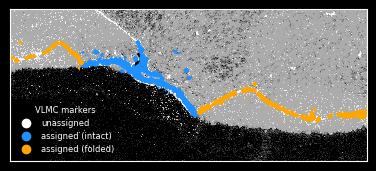

In [15]:
endothelial_markers = ("Aldh1a2", "Col1a1", "Fmod", "Slc13a4")

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(13.5 * CM, 5 * CM))

    scatter_kwargs = dict(x="x", y="y", rasterized=True, ax=ax, lw=0)

    sns.scatterplot(
        data=coordinate_df_3d[coordinate_df_3d["y"].between(*ylim)],
        s=0.5,
        alpha=0.1,
        c="dimgrey",
        **scatter_kwargs,
    )
    sns.scatterplot(
        data=coordinate_df_3d[
            lambda df: df["y"].between(*ylim) & df["gene"].isin(endothelial_markers)
        ],
        s=0.5,
        alpha=0.5,
        c="white",
        **scatter_kwargs,
    )
    sns.scatterplot(
        data=coordinate_df_3d_clean_vlmcs, s=1, c="dodgerblue", **scatter_kwargs
    )
    sns.scatterplot(data=coordinate_df_3d_fold_vlmcs, s=1, c="orange", **scatter_kwargs)

    plt.legend(
        handles=[
            plt.scatter([], [], c=c, label=l)
            for c, l in zip(
                ["white", "dodgerblue", "orange"],
                ["unassigned", "assigned (intact)", "assigned (folded)"],
            )
        ],
        title="VLMC markers",
        frameon=False,
        loc="lower left",
    )

    ax.set(**ax_kwargs, **ax_lims)

    fig.savefig("baysor_vlmcs.svg", **save_kwargs)

In [16]:
coordinate_df_3d["celltypes_short"] = (
    coordinate_df_3d["celltype"].str.split(" ").str[-1]
)
coordinate_df_3d.loc[
    coordinate_df_3d["cluster"].str.contains("VLMC", na=False), "celltypes_short"
] = "VLMC"
coordinate_df_3d["celltypes_short"] = coordinate_df_3d["celltypes_short"].astype(
    "category"
)

In [17]:
from matplotlib.cm import Set3

celltypes = coordinate_df_3d["celltypes_short"].cat.categories

ct_cmap = dict(zip(celltypes, Set3(np.linspace(0, 0.93, len(celltypes)))))

In [18]:
ct_scatter_kwargs = dict(
    x="x",
    y="y",
    hue="celltypes_short",
    rasterized=True,
    palette=ct_cmap,
    legend=False,
    lw=0,
)

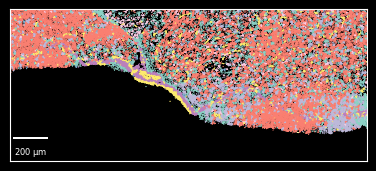

In [19]:
with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(13.5 * CM, 5 * CM))

    sns.scatterplot(
        data=coordinate_df_3d[lambda df: df.y.between(*ylim) & df.x.between(*xlim)][
            ::10
        ],
        s=0.5,
        ax=ax,
        **ct_scatter_kwargs,
    )

    ax.set(**ax_kwargs, **ax_lims)

    ax.add_artist(ScaleBar(1, units="um", frameon=False, color="w", loc="lower left"))

    fig.savefig("baysor_3d_celltypes.svg", **save_kwargs)

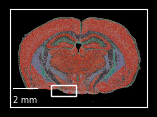

In [20]:
with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(4.5 * CM, 5 * CM))

    sns.scatterplot(data=coordinate_df_3d[::50], s=0.01, ax=ax, **ct_scatter_kwargs)

    ax.set(**ax_kwargs)
    ax.add_artist(
        plt.Rectangle(
            (xlim[0], ylim[0]),
            xlim[1] - xlim[0],
            ylim[1] - ylim[0],
            fill=False,
            edgecolor="w",
            lw=1,
        )
    )
    ax.add_artist(ScaleBar(1, units="um", frameon=False, color="w", loc="lower left"))

    fig.savefig("baysor_3d_celltypes_global.svg", **save_kwargs)

/tmp/ipykernel_991066/2557283169.py:3: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles=[plt.scatter([], [], c=c, label=l) for l, c in ct_cmap.items()],


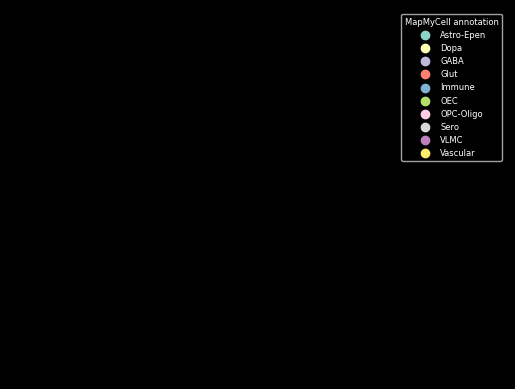

In [21]:
with plt.style.context("dark_background"):
    plt.legend(
        handles=[plt.scatter([], [], c=c, label=l) for l, c in ct_cmap.items()],
        title="MapMyCell annotation",
    )
    plt.axis("off")

    plt.savefig("baysor_3d_celltypes_legend.svg", **save_kwargs)

#### Slice up the VLMC into a 'clean' and 'folded' part, show that we have DEGs that are e.g. Astrocyte markers;

In [22]:
# ovrlpy analysis is shifted compared to original coordinates
origin = (
    ovrlpy.io.read_Xenium(data_folder / "transcripts.parquet").select(("x", "y")).min()
)

x_origin, y_origin = origin.row(0)

xlim_shift = tuple(x - round(x_origin) for x in xlim)
ylim_shift = tuple(y - round(y_origin) for y in ylim)

In [23]:
import pickle

with open("../xenium_brain.pickle", "rb") as file:
    brain = pickle.load(file)

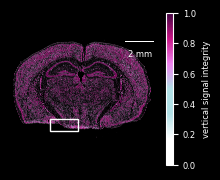

In [24]:
fig = ovrlpy.plot_signal_integrity(
    brain,
    histogram=False,
    scalebar=dict(dx=1, units="um", frameon=False, color="w"),
    figsize=(6 * CM, 5 * CM),
)

ax = fig.axes[0]
ax.set(xticks=[], yticks=[])
ax.set_axis_off()
ax.add_artist(
    plt.Rectangle(
        (xlim_shift[0], ylim_shift[0]),
        xlim_shift[1] - xlim_shift[0],
        ylim_shift[1] - ylim_shift[0],
        fill=False,
        edgecolor="w",
        lw=1,
    )
)

fig.savefig("signal_integrity.svg", **save_kwargs)

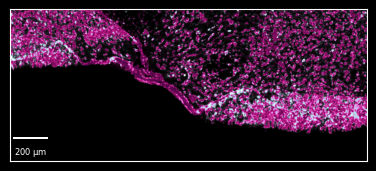

In [25]:
integrity = brain.integrity_map.copy()

xrange = slice(*xlim_shift)
yrange = slice(*ylim_shift)

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(13.5 * CM, 5 * CM))

    _plot_signal_integrity(
        ax, integrity[yrange, xrange], brain.signal_map[yrange, xrange], 2
    )

    ax.set(xticks=[], yticks=[])
    ax.add_artist(ScaleBar(1, units="um", frameon=False, color="w", loc="lower left"))

    fig.savefig("signal_integrity_area.svg", **save_kwargs)

In [26]:
signal_integrity = brain.integrity_map.copy()
signal_strength = brain.signal_map.copy()

In [27]:
signal_integrity[signal_strength == 0] = np.nan

cells["sampled_integrity"] = signal_integrity[
    (cells["centroid_y"] - y_origin).astype(int),
    (cells["centroid_x"] - x_origin).astype(int),
]
cells["correlation"] = mapmycells_df["subclass_correlation_coefficient"][cells.index]

In [28]:
from scipy.stats import PermutationMethod, pearsonr

isna = cells["sampled_integrity"].isna()
pearson, p = pearsonr(
    cells["correlation"][~isna],
    cells["sampled_integrity"][~isna],
    method=PermutationMethod(n_resamples=10_000, random_state=42),
)

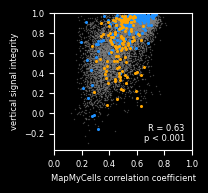

In [29]:
def p_string(p: float):
    if p < 0.001:
        return "p < 0.001"
    elif p < 0.01:
        return "p < 0.01"
    else:
        return f"{p:.2f}"


with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(4.5 * CM, 4.5 * CM))

    scatter_kwargs = dict(
        x="correlation",
        y="sampled_integrity",
        lw=0,
        ax=ax,
        rasterized=True,
    )

    plain_vlmc_mask[isna] = False
    overlap_vlmc_mask[isna] = False

    sns.scatterplot(
        data=cells[area_of_interest], s=1, c="grey", alpha=0.5, **scatter_kwargs
    )

    sns.scatterplot(data=cells[plain_vlmc_mask], s=5, c="dodgerblue", **scatter_kwargs)
    sns.scatterplot(data=cells[overlap_vlmc_mask], s=5, c="orange", **scatter_kwargs)

    ax.set(
        xlabel="MapMyCells correlation coefficient",
        ylabel="vertical signal integrity",
        xlim=(0, 1),
        ylim=(None, 1),
    )
    ax.text(
        s=f"R = {pearson:.2f}\n{p_string(p)}",
        ha="right",
        va="top",
        x=0.95,
        y=-0.1,
        color="w",
    )

fig.savefig("baysor_integrity_correlation.svg", **save_kwargs)

In [30]:
from scipy.stats import mannwhitneyu

mannwhitneyu(
    cells.loc[plain_vlmc_mask, "sampled_integrity"],
    cells.loc[overlap_vlmc_mask, "sampled_integrity"],
    alternative="greater",
)

MannwhitneyuResult(statistic=19735.0, pvalue=3.3340808074516893e-18)